# **IMPORT NECESSARY LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **LOAD DATASET**

In [2]:
 df = pd.read_csv('imbalanced_dataset_final.csv')
 df.shape

(8623, 3)

In [3]:
# Initial Data Cleaning
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

# Handle missing values in 'Review' column by converting them to empty strings
df['Review'] = df['Review'].fillna('')
y_rating_original = df['Rating'].astype(int) # Ensure target is integer

print("--- Data Initialized ---")
print(f"Total Records: {len(df)}")
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution:")
print(y_rating_original.value_counts())

--- Data Initialized ---
Total Records: 8623

First 5 rows:
   Rating                                             Review
0       3  nice product surfing mobile network broadband ...
1       1                     month left minutes temparature
2       4         ossmm product good qualitybetter packaging
3       4  think best product prize totally worth get bag...
4       2  genuine product timex qr code work timex app s...

Class distribution:
Rating
4    2185
5    2065
2    1658
3    1615
1    1100
Name: count, dtype: int64


# **TRAIN TEST SPLIT**

In [4]:
# Define features (X) and target (y)
X_text = df['Review']
y = y_rating_original

# Stratified Split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    stratify=y, # Ensures the class proportion is maintained in both splits
    random_state=42
)

print("\n--- Train Test Split Completed ---")
print(f"Training set size: {len(X_train_text)}")
print(f"Test set size: {len(X_test_text)}")

# --- Text Vectorization (TF-IDF) ---
# Fit TfidfVectorizer only on the training data to prevent data leakage
tfidf = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print(f"Feature matrix shape after TF-IDF: {X_train.shape}")


--- Train Test Split Completed ---
Training set size: 6898
Test set size: 1725
Feature matrix shape after TF-IDF: (6898, 10000)


# **DATA VISUALIZATION OF TRAINING**

/tmp/ipython-input-2901783861.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, order=sorted(y_train.unique()), palette='coolwarm')
/tmp/ipython-input-2901783861.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, order=sorted(y_test.unique()), palette='coolwarm')


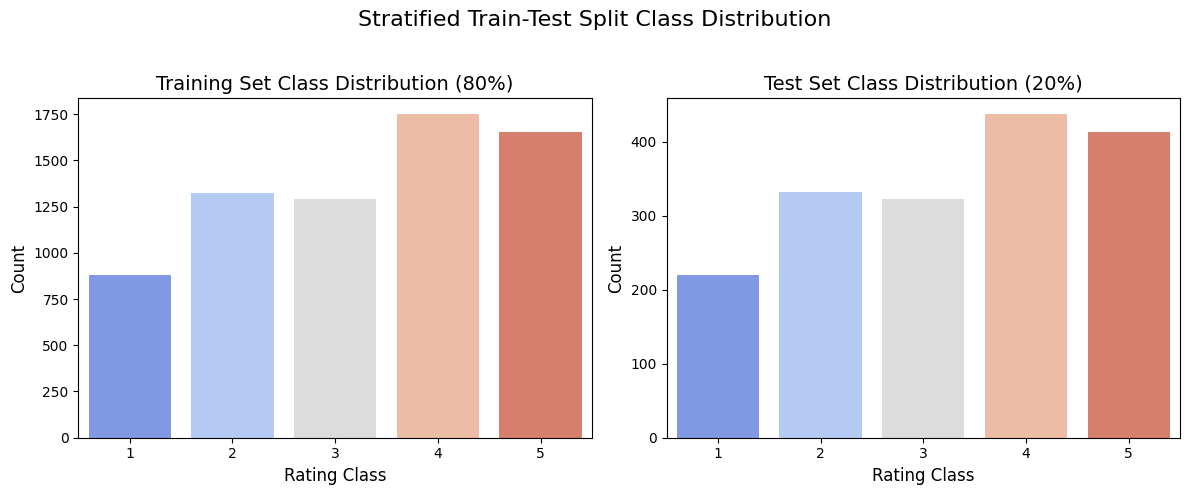

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, order=sorted(y_train.unique()), palette='coolwarm')
plt.title('Training Set Class Distribution (80%)', fontsize=14)
plt.xlabel('Rating Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.subplot(1, 2, 2)
sns.countplot(x=y_test, order=sorted(y_test.unique()), palette='coolwarm')
plt.title('Test Set Class Distribution (20%)', fontsize=14)
plt.xlabel('Rating Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.suptitle('Stratified Train-Test Split Class Distribution', fontsize=16)
plt.tight_layout(rect=[0, 0.0, 1, 0.95]) # Adjust for suptitle
plt.show()

# **MODELLING**

In [10]:
# Dictionary to hold trained models for later access
trained_models = {}

# Define the models to train
models_to_train = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr', max_iter=1000),
    'SVM': SVC(random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=200, n_jobs=-1)
}

results = {}
best_model_name = None
best_model = None
best_accuracy = 0

print("\n" + "="*70)
print("Starting Model Training and Evaluation (Logistic Regression, SVM, Naive Bayes, Random Forest)")
print("="*70)

for name, model in models_to_train.items():
    print(f"\n--- Training {name} ---")

    # Train the model
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    conf_mat = confusion_matrix(y_test, y_pred)
    class_report_str = classification_report(y_test, y_pred)

    # Store results for visualization
    results[name] = {'accuracy': accuracy, 'report': class_report_str}

    # Print results
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report (Precision, Recall, F1-score, Support):")
    print(class_report_str)
    print("\nConfusion Matrix:")
    print(conf_mat)

    # Track best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = name
        best_model = model

print("\n" + "="*70)
print(f"BEST MODEL IDENTIFIED: {best_model_name} with Accuracy: {best_accuracy:.4f}")
print("="*70)


Starting Model Training and Evaluation (Logistic Regression, SVM, Naive Bayes, Random Forest)

--- Training Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.4690

Classification Report (Precision, Recall, F1-score, Support):
              precision    recall  f1-score   support

           1       0.56      0.45      0.49       220
           2       0.44      0.44      0.44       332
           3       0.42      0.29      0.34       323
           4       0.42      0.52      0.46       437
           5       0.54      0.59      0.56       413

    accuracy                           0.47      1725
   macro avg       0.48      0.46      0.46      1725
weighted avg       0.47      0.47      0.46      1725


Confusion Matrix:
[[ 98  77  23  10  12]
 [ 60 145  56  56  15]
 [ 14  69  93 112  35]
 [  4  20  36 228 149]
 [  0  15  12 141 245]]

--- Training SVM ---
Accuracy: 0.4614

Classification Report (Precision, Recall, F1-score, Support):
              precision    recall  f1-score   support

           1       0.59      0.37      0.46       220
           2       0.43      0.48      0.45       332
           3       0.42      0.

# **DATA VISUALIZATION OF MODELLING**

/tmp/ipython-input-2862880948.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sorted_names, y=sorted_accuracies, palette=colors)


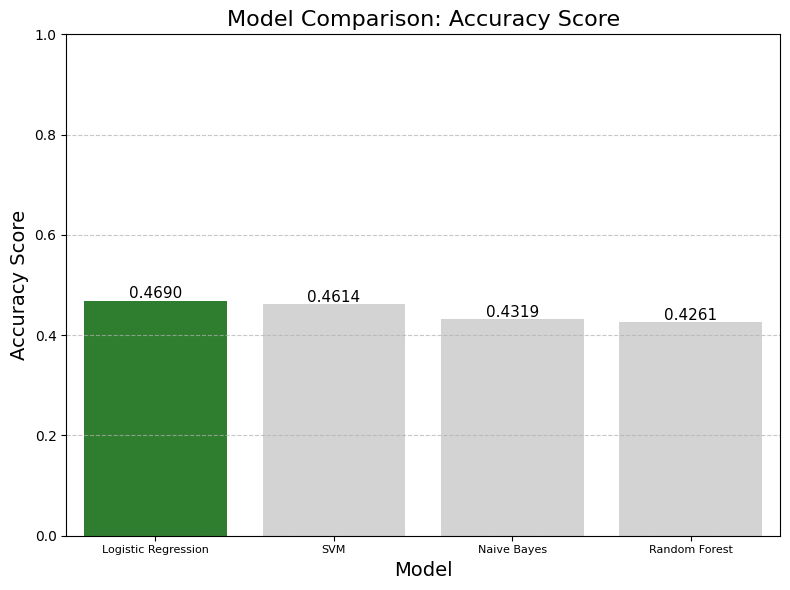

In [11]:
# Prepare data for plotting
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]

# Sort models by accuracy for better visualization
sorted_indices = np.argsort(accuracies)[::-1]
sorted_names = [model_names[i] for i in sorted_indices]
sorted_accuracies = [accuracies[i] for i in sorted_indices]

plt.figure(figsize=(8, 6))
# Define a color map
colors = ['lightgrey'] * len(sorted_names)
best_index = sorted_names.index(best_model_name)
colors[best_index] = 'forestgreen' # Highlight the best model

# Create the bar plot
ax = sns.barplot(x=sorted_names, y=sorted_accuracies, palette=colors)

# Add accuracy values on top of the bars
for i, acc in enumerate(sorted_accuracies):
    ax.text(i, acc + 0.005, f'{acc:.4f}', ha='center', fontsize=11, color='black')

plt.title('Model Comparison: Accuracy Score', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy Score', fontsize=14)
plt.ylim(0, 1.0)
plt.xticks(rotation=0, ha='center', fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **DOWNLOAD BEST MODEL**

In [12]:
# Define filenames
model_filename = 'Model_B.pkl'
vectorizer_filename = 'imbalanced_tfidf_vectorizer.pkl'

if best_model is not None:
    try:
        # Save the best model object
        with open(model_filename, 'wb') as file:
            pickle.dump(best_model, file)

        # Save the trained TF-IDF vectorizer object
        with open(vectorizer_filename, 'wb') as file:
            pickle.dump(tfidf, file)

        print("\n" + "="*70)
        print("SUCCESS: Model and Vectorizer Saved for Download!")
        print(f"Best Model ('{best_model_name}') saved as: {model_filename}")
        print(f"TF-IDF Vectorizer saved as: {vectorizer_filename}")
        print("="*70)

        # Download the files
        files.download(model_filename)
        files.download(vectorizer_filename)
        print("="*70)

    except Exception as e:
        print(f"ERROR: Could not save files using pickle. {e}")

else:
    print("ERROR: Best model object was not found.")


SUCCESS: Model and Vectorizer Saved for Download!
Best Model ('Logistic Regression') saved as: Model_B.pkl
TF-IDF Vectorizer saved as: imbalanced_tfidf_vectorizer.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>